# Quantitative Finance Lab: Portfolio Optimization
This notebook explores Modern Portfolio Theory (MPT) by calculating efficient frontiers, finding Minimum Variance Portfolios (MVP), and analyzing the impact of risk-free assets and transaction costs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    dati = pd.read_excel('Lab3-students.xlsx', sheet_name=1)

    # Calculate gross daily returns in chronological order
    rend_amazon = (dati['AMAZON.COM'].values[:-1] / dati['AMAZON.COM'].values[1:])[::-1]
    rend_facebook = (dati['FACEBOOK CLASS A'].values[:-1] / dati['FACEBOOK CLASS A'].values[1:])[::-1]
    rend_apple = (dati['APPLE'].values[:-1] / dati['APPLE'].values[1:])[::-1]

    R_all = np.column_stack((rend_amazon, rend_facebook, rend_apple))
except FileNotFoundError:
    print("Please upload 'Lab3-students.xlsx'.")

## 1. Efficient Frontiers and Minimum Variance Portfolios
The efficient frontier represents the set of portfolios that minimize variance for a given expected return. The mathematical objective is to minimize $\frac{1}{2}w^T V w$ subject to budget and target return constraints. The Minimum Variance Portfolio (MVP) represents the lowest possible risk, visually located at the leftmost point of the curve.

As shown below, comparing Frontier A (Amazon & Facebook), Frontier B (Facebook & Apple), and Frontier C (All three assets), the inclusion of a third asset improves diversification. This broader asset base shifts the MVP further to the left, achieving a lower standard deviation than the two-asset combinations.

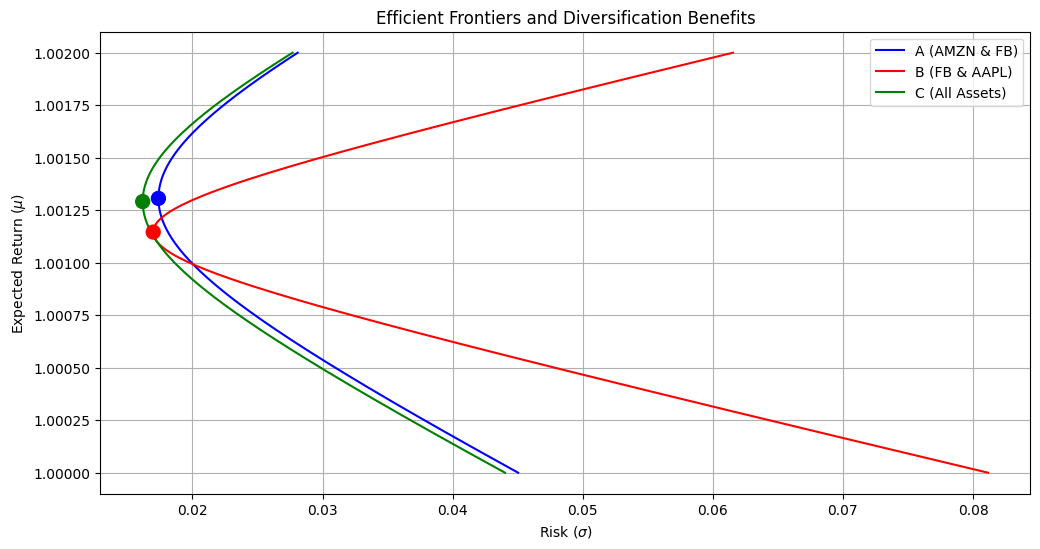

In [ ]:
def get_frontier(R):
    mu = np.mean(R, axis=0)
    V = np.cov(R, rowvar=False)
    Vi = np.linalg.inv(V)
    uno = np.ones(len(mu))

    A, B, C = uno.T @ Vi @ mu, mu.T @ Vi @ mu, uno.T @ Vi @ uno
    D = B * C - A**2
    g, h = (B*(Vi@uno) - A*(Vi@mu))/D, (C*(Vi@mu) - A*(Vi@uno))/D

    w_mvp = (Vi @ uno) / C
    return V, g, h, w_mvp, mu.T @ w_mvp, np.sqrt(w_mvp.T @ V @ w_mvp)

mu_range = np.linspace(1, 1.002, 200)

# Calculate parameters for all combinations
_, g_A, h_A, _, mu_mvp_A, sig_mvp_A = get_frontier(R_all[:, [0, 1]])
_, g_B, h_B, _, mu_mvp_B, sig_mvp_B = get_frontier(R_all[:, [1, 2]])
V_C, g_C, h_C, _, mu_mvp_C, sig_mvp_C = get_frontier(R_all)

sig_A = [np.sqrt((g_A + h_A*m).T @ np.cov(R_all[:, [0, 1]], rowvar=False) @ (g_A + h_A*m)) for m in mu_range]
sig_B = [np.sqrt((g_B + h_B*m).T @ np.cov(R_all[:, [1, 2]], rowvar=False) @ (g_B + h_B*m)) for m in mu_range]
sig_C = [np.sqrt((g_C + h_C*m).T @ V_C @ (g_C + h_C*m)) for m in mu_range]

plt.figure(figsize=(12, 6))
plt.plot(sig_A, mu_range, 'b-', label='A (AMZN & FB)')
plt.plot(sig_B, mu_range, 'r-', label='B (FB & AAPL)')
plt.plot(sig_C, mu_range, 'g-', label='C (All Assets)')
plt.scatter([sig_mvp_A, sig_mvp_B, sig_mvp_C], [mu_mvp_A, mu_mvp_B, mu_mvp_C], color=['blue', 'red', 'green'], s=100, zorder=5)
plt.title('Efficient Frontiers and Diversification Benefits')
plt.xlabel(r'Risk ($\sigma$)'); plt.ylabel(r'Expected Return ($\mu$)')
plt.legend(); plt.grid(True); plt.show()

## 2. Risk-Free Asset and Quadratic Utility
Introducing a risk-free asset expands the reachable risk-return combinations, turning the frontier into two half-lines originating at $(0, r_f)$.

Assuming a quadratic utility function with a very low absolute risk aversion coefficient ($b=0.001$), the investor heavily favors high expected returns and barely penalizes variance. The optimal portfolio becomes proportional to the risk premium vector $e - r_f 1$ pre-multiplied by the inverse of the covariance matrix. Because risk is barely penalized, the model suggests an extreme, unrealistic use of financial leverage (massive short selling of the risk-free asset and Facebook) to maximize returns.

In [ ]:
avers, rf_giorn = 0.002, 1.01 ** (1/252)
mu_C = np.mean(R_all, axis=0)

pesi_risk = (1/avers) * np.linalg.inv(V_C) @ (mu_C - rf_giorn)
peso_rf = 1 - np.sum(pesi_risk)

print(f"Optimal Weights (Quadratic Utility):\nAMZN: {pesi_risk[0]:.2f} | FB: {pesi_risk[1]:.2f} | AAPL: {pesi_risk[2]:.2f} | Risk-Free: {peso_rf:.2f}")

Optimal Weights (Quadratic Utility):
AMZN: 1832.30 | FB: -357.05 | AAPL: 917.88 | Risk-Free: -2392.13


## 3. Transaction Costs Penalty
To address the unrealistic leveraged positions obtained previously, we solve an optimization problem that maximizes utility penalized by transaction costs:
$\max w^T\mu - \frac{\alpha}{2}w^T V w - \frac{1}{2}(w-w_0)^T \Lambda (w-w_0)$.

The penalty term forces the allocation to stay close to an initial equally-weighted portfolio $w_0$. The result completely eliminates extreme short selling, distributing the weights evenly among the three assets. This ensures proper utilization of the assets' covariances, restoring realistic and effective portfolio diversification.

In [ ]:
alpha, w0 = 3, np.array([1/3, 1/3, 1/3])
Lambda = np.diag([0.003, 0.003, 0.001])
uno3 = np.ones(3)

H = alpha * V_C + Lambda
mu_til = mu_C + Lambda @ w0
H_inv = np.linalg.inv(H)

lam = (uno3.T @ (H_inv @ mu_til) - 1) / (uno3.T @ (H_inv @ uno3))
w_ott = H_inv @ (mu_til - lam * uno3)

print(f"Optimal Weights (Transaction Costs):\nAMZN: {w_ott[0]:.4f} | FB: {w_ott[1]:.4f} | AAPL: {w_ott[2]:.4f}")

Optimal Weights (Transaction Costs):
AMZN: 0.4119 | FB: 0.2389 | AAPL: 0.3493
